In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
df = pd.read_csv('FloridaBikeRentals.csv', encoding='ISO-8859-1')


In [116]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [118]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [119]:
df[['Seasons', 'Holiday', 'Functioning Day']].value_counts()

Seasons  Holiday     Functioning Day
Summer   No Holiday  Yes                2160
Spring   No Holiday  Yes                2088
Winter   No Holiday  Yes                1968
Autumn   No Holiday  Yes                1841
                     No                  223
Winter   Holiday     Yes                 192
Autumn   Holiday     Yes                  96
Spring   Holiday     Yes                  72
         No Holiday  No                   48
Summer   Holiday     Yes                  48
Autumn   Holiday     No                   24
Name: count, dtype: int64

## FloridaBikeRentals.csv – Dataset Description

| **Variable**            | **Description**                                                                 |
|-------------------------|---------------------------------------------------------------------------------|
| **Date**                | Date in day/month/year format                                                   |
| **Rented Bike count**   | Count of bikes rented each hour                                                 |
| **Hour**                | Hour of the day                                                                 |
| **Temperature**         | Temperature in Celsius                                                          |
| **Humidity**            | Humidity in percentage                                                          |
| **Snowfall**            | Snowfall in cm                                                                  |
| **Holiday**             | Is it a holiday? Holiday / No holiday                                           |
| **Windspeed**           | Speed of the wind in meters per second (m/s)                                    |
| **Visibility**          | Visibility in meters                                                            |
| **Dew point temperature** | Dew point temperature in Celsius                                              |
| **Solar radiation**     | Radiant energy from the sun measured in MJ/m²                                   |
| **Rainfall**            | Rainfall in mm                                                                  |
| **Seasons**             | Season of the year – Winter, Summer, Spring, and Fall                           |
| **Functional Day**      | Bike rented during functional (Fun) and nonfunctional hours (NoFunc)            |


In [120]:
df['Date']

0       01/12/2017
1       01/12/2017
2       01/12/2017
3       01/12/2017
4       01/12/2017
           ...    
8755    30/11/2018
8756    30/11/2018
8757    30/11/2018
8758    30/11/2018
8759    30/11/2018
Name: Date, Length: 8760, dtype: object

In [123]:
# Convert 'Date' column with day/month/year format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract day
df['Day'] = df['Date'].dt.day

# Extract month
df['Month'] = df['Date'].dt.month

# Extract day of week
df['DayOfWeek'] = df['Date'].dt.day_name()

# Determine if it's a weekday or weekend
df['WeekPart'] = df['DayOfWeek'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

# Preview result
df[['Date', 'Day', 'Month', 'DayOfWeek', 'WeekPart']].head()


,Date,Day,Month,DayOfWeek,WeekPart
0,2017-12-01,1,12,Friday,Weekday
1,2017-12-01,1,12,Friday,Weekday
2,2017-12-01,1,12,Friday,Weekday
3,2017-12-01,1,12,Friday,Weekday
4,2017-12-01,1,12,Friday,Weekday


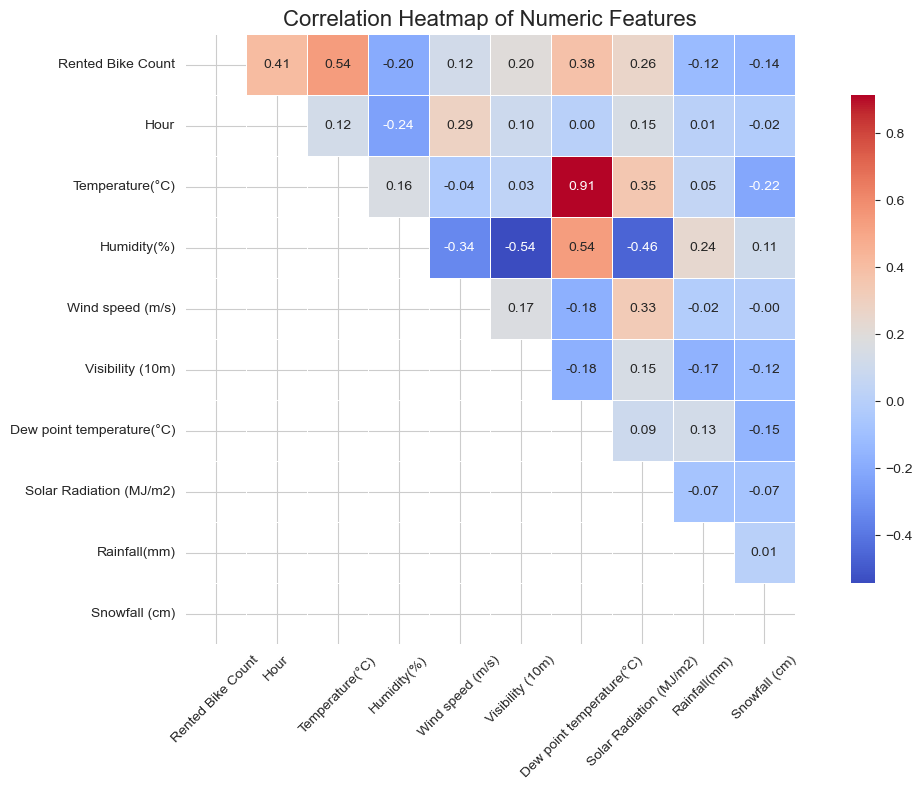

In [124]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Create a mask for the lower triangle and diagonal
mask = np.tril(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap with the mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})

# Title and layout
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


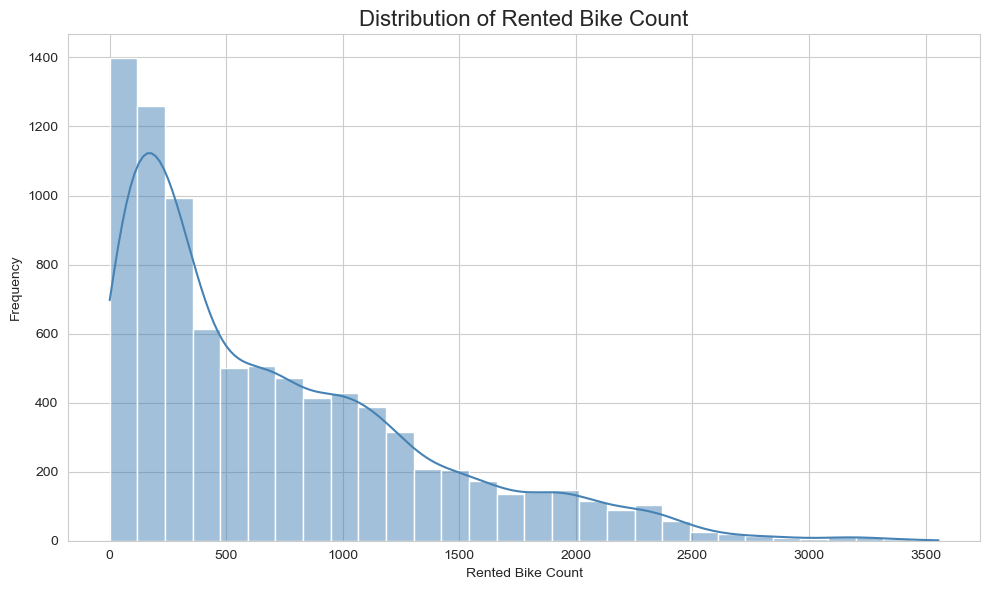

In [125]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(df['Rented Bike Count'], kde=True, bins=30, color='steelblue')

plt.title("Distribution of Rented Bike Count", fontsize=16)
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


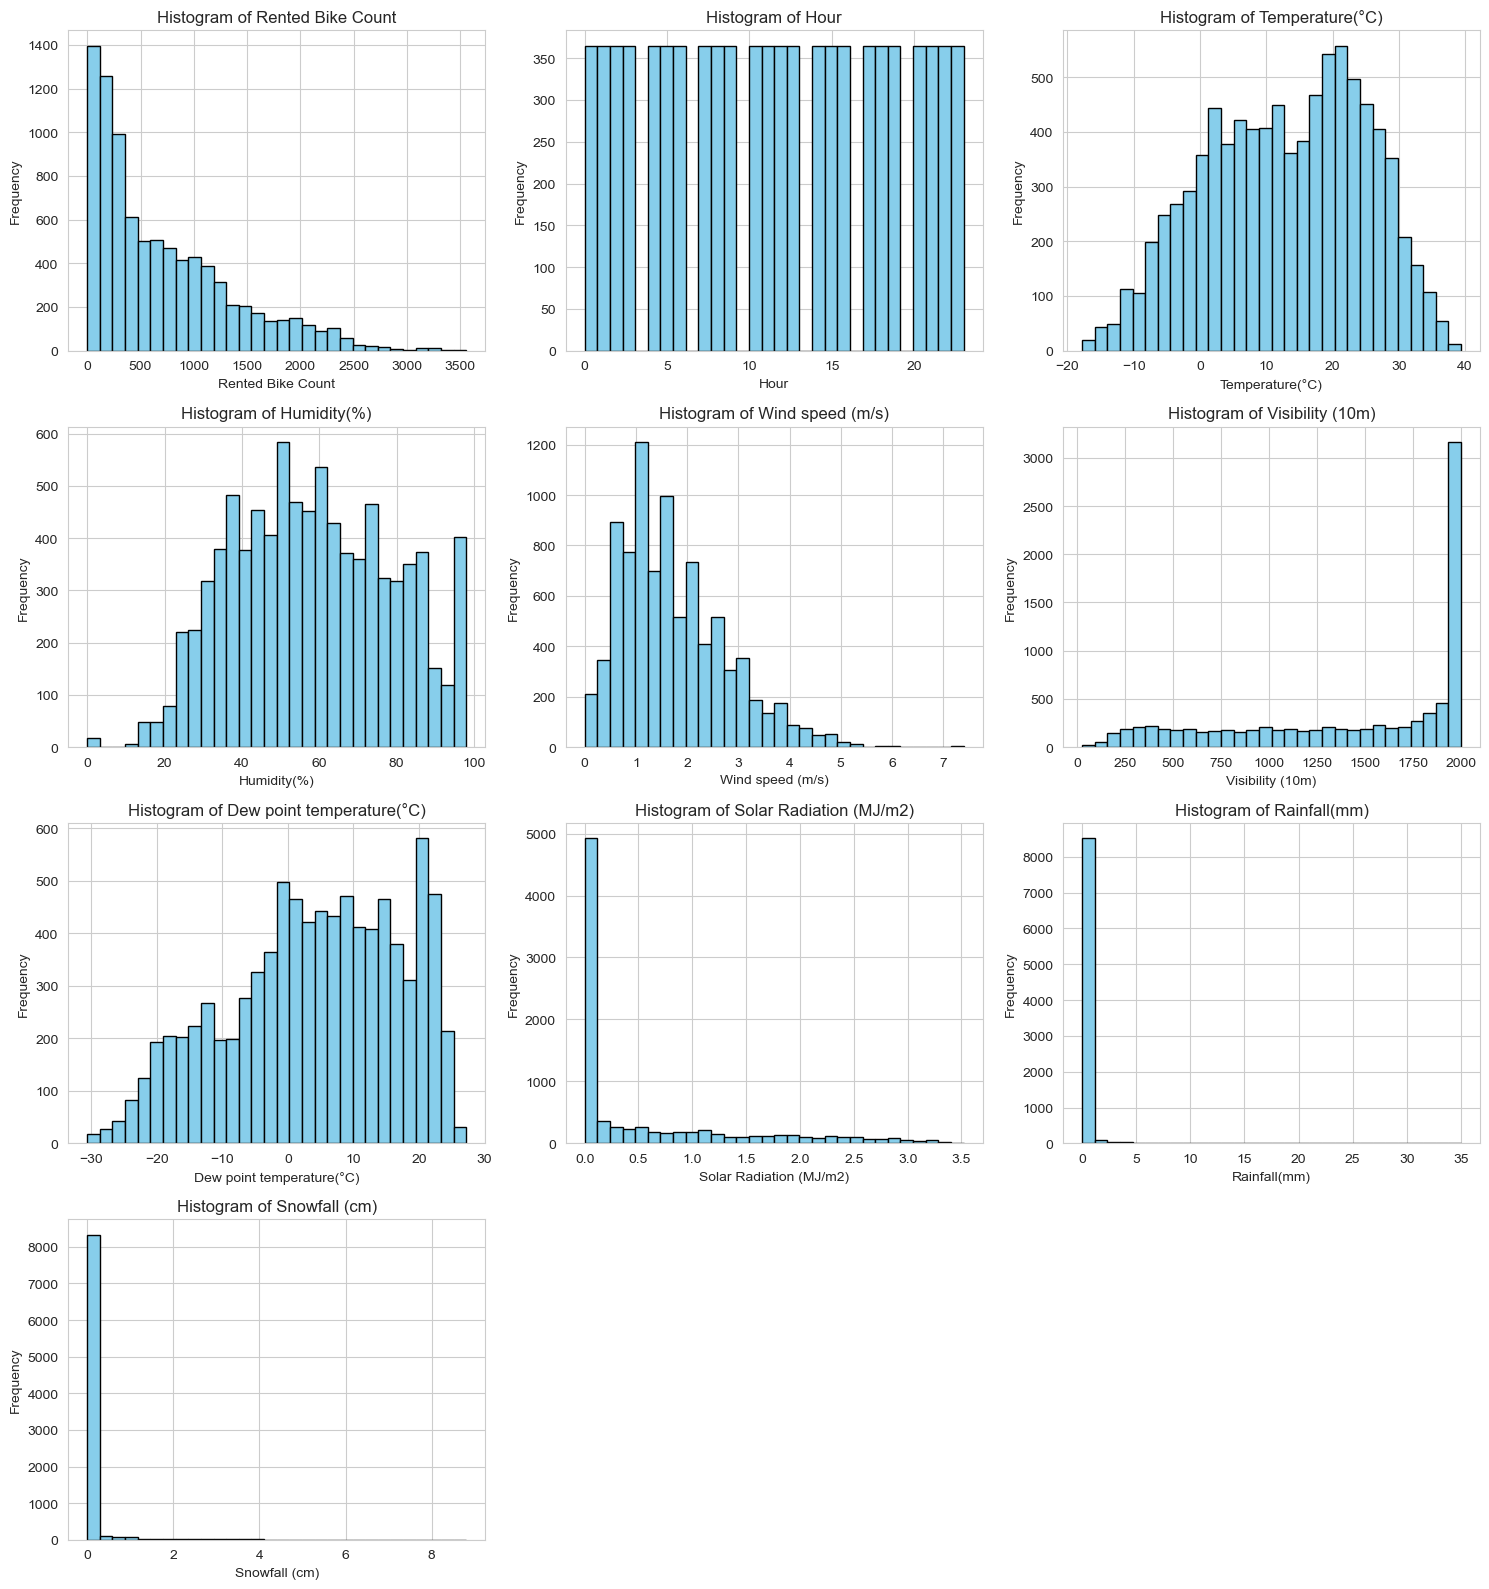

In [126]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

n_cols = 3  # number of plots per row
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # Flatten to simplify indexing

# Plot each histogram
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Layout
plt.tight_layout()
plt.show()


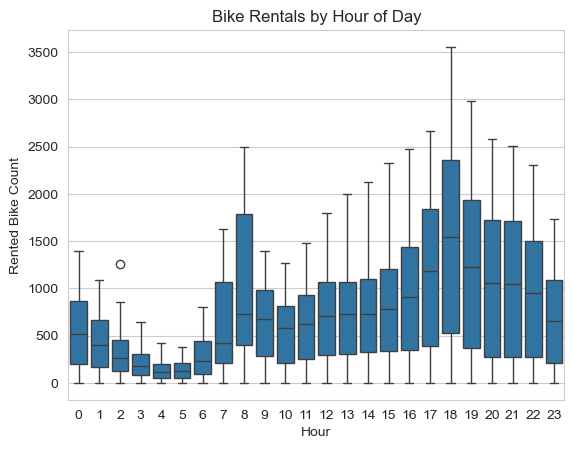

In [127]:
sns.boxplot(x='Hour', y='Rented Bike Count', data=df)
plt.title("Bike Rentals by Hour of Day")
plt.show()


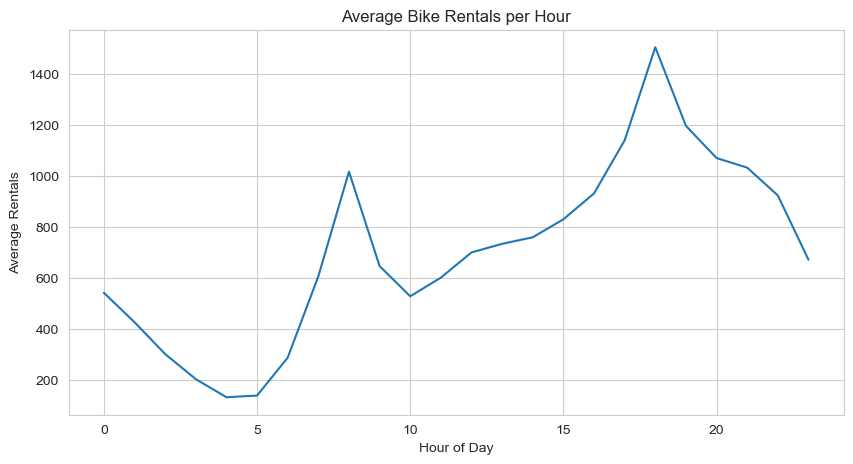

In [128]:
hourly_avg = df.groupby('Hour')['Rented Bike Count'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values)
plt.title("Average Bike Rentals per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.show()


C:\Users\jerom\AppData\Local\Temp\ipykernel_45288\3878699860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Rented Bike Count', data=df, hue=None, palette='Set3')


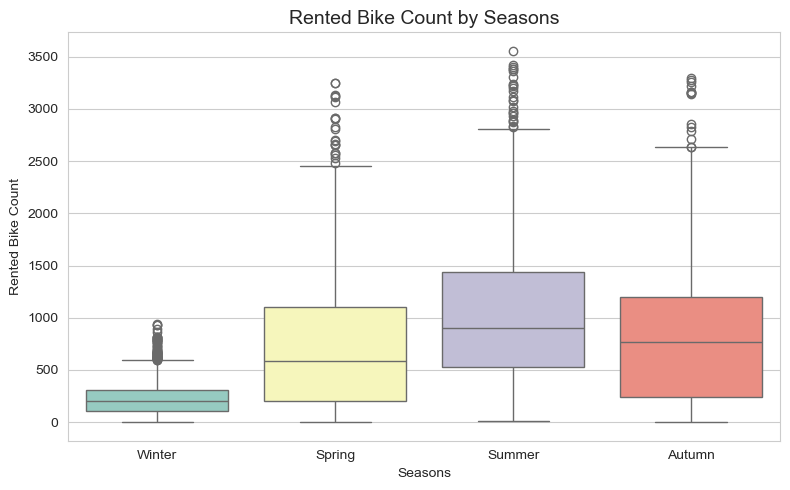

C:\Users\jerom\AppData\Local\Temp\ipykernel_45288\3878699860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Rented Bike Count', data=df, hue=None, palette='Set3')


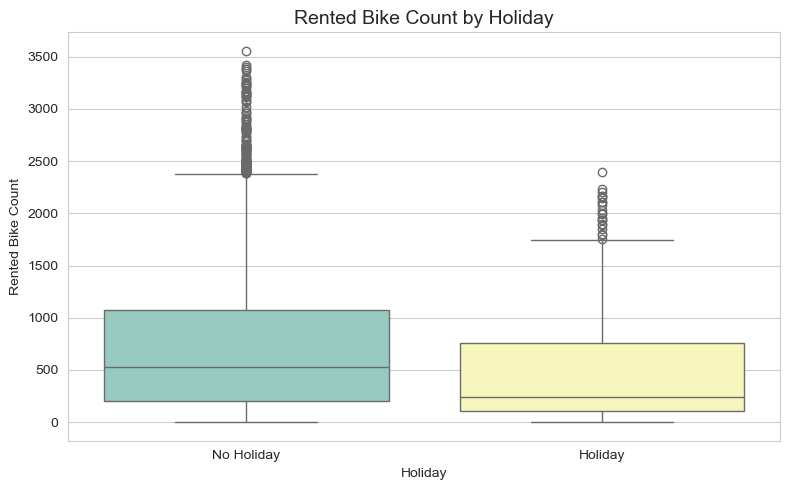

C:\Users\jerom\AppData\Local\Temp\ipykernel_45288\3878699860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Rented Bike Count', data=df, hue=None, palette='Set3')


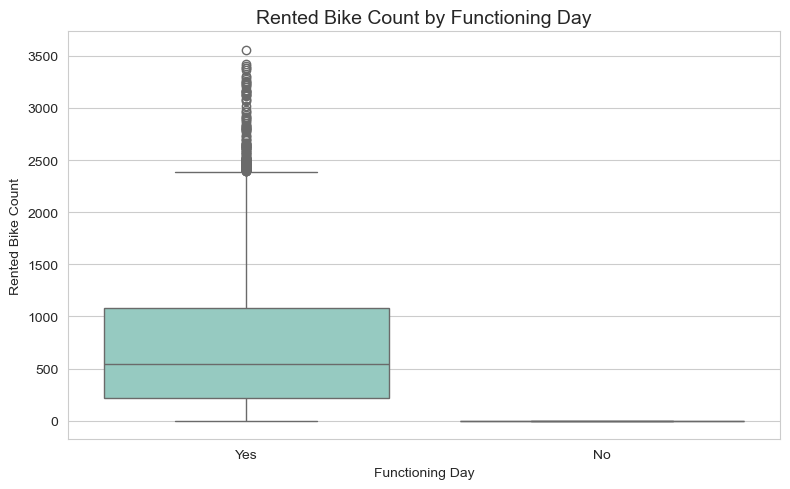

In [129]:
categorical_cols = ['Seasons', 'Holiday', 'Functioning Day']

# Plot box plots
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=col, y='Rented Bike Count', data=df, hue=None, palette='Set3')
    plt.title(f"Rented Bike Count by {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Rented Bike Count")
    plt.tight_layout()
    plt.show()


dict_keys(['Hour', 'Holiday', 'Rainfall(mm)', 'Snowfall (cm)', 'WeekPart'])

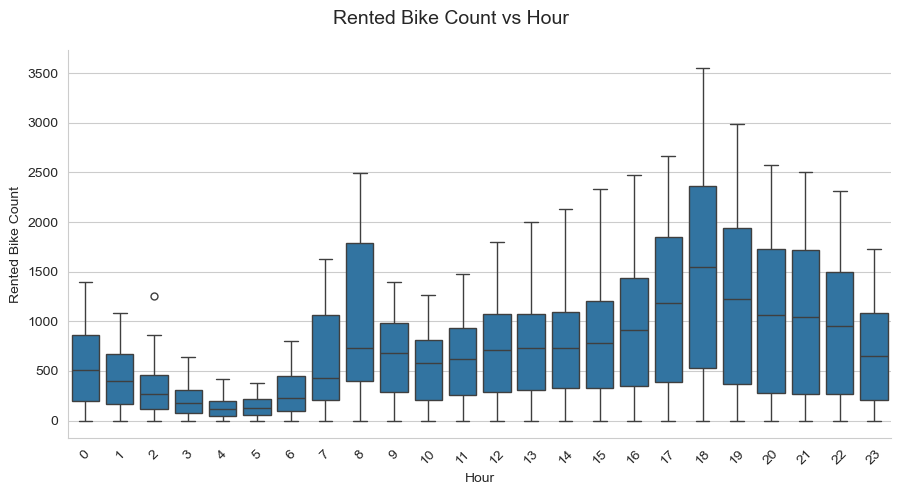

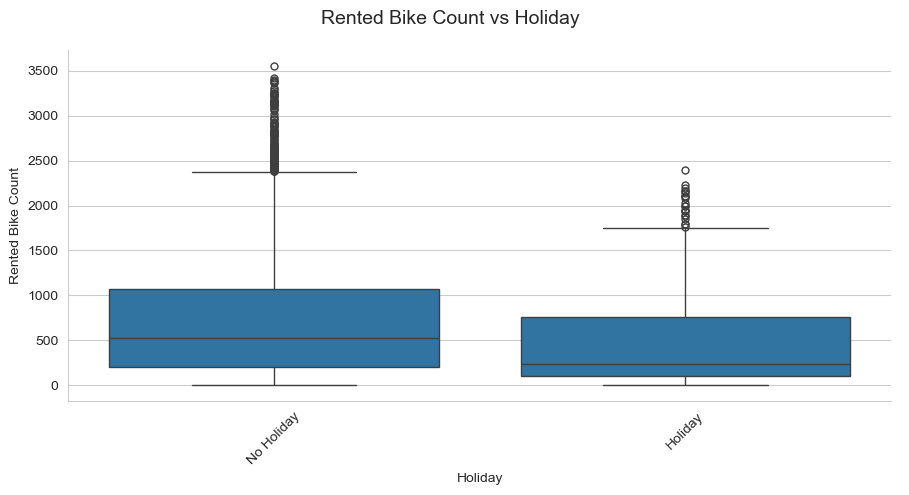

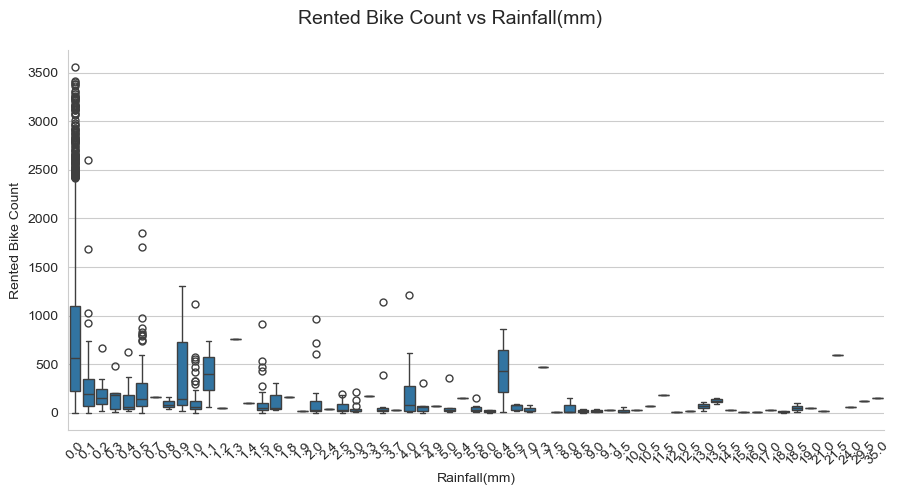

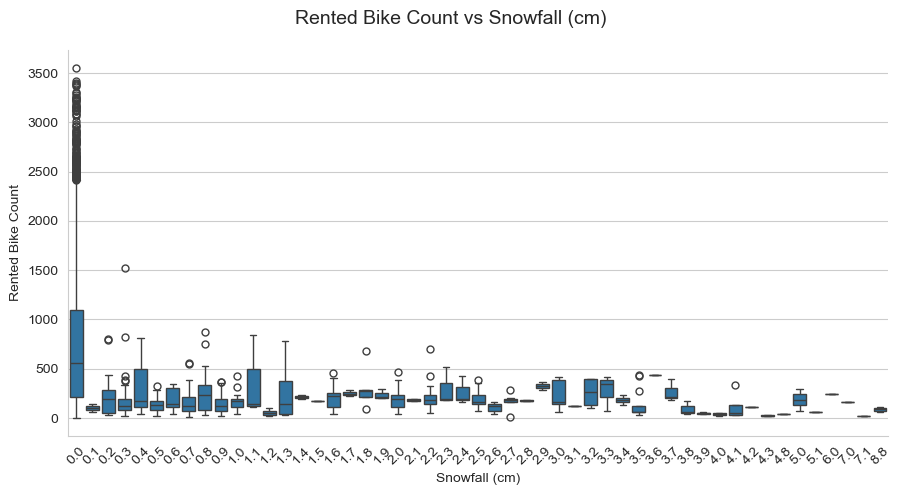

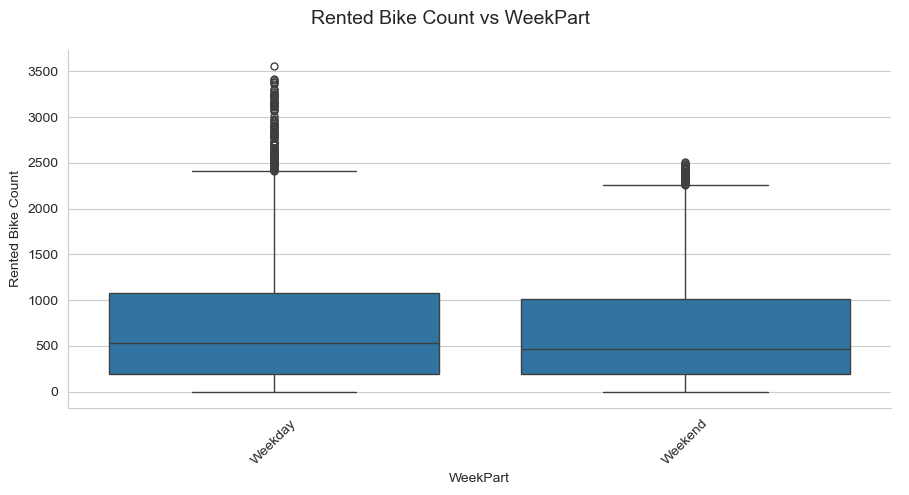

In [130]:
features_to_plot = ['Hour', 'Holiday', 'Rainfall(mm)', 'Snowfall (cm)', 'WeekPart']

catplots = {}
for feature in features_to_plot:
    g = sns.catplot(x=feature, y='Rented Bike Count', kind='box', data=df, height=5, aspect=1.8)
    g.fig.suptitle(f"Rented Bike Count vs {feature}", fontsize=14)
    g.set_xticklabels(rotation=45)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    catplots[feature] = g

catplots.keys()


In [131]:
# List of categorical columns to encode
categorical_cols = ['Seasons', 'Holiday', 'Functioning Day', 'WeekPart']

# Create one-hot encoded dataframe
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the new columns added
df_encoded.columns.difference(df.columns)

Index(['Functioning Day_Yes', 'Holiday_No Holiday', 'Seasons_Spring',
       'Seasons_Summer', 'Seasons_Winter', 'WeekPart_Weekend'],
      dtype='object')

In [132]:
df_encoded.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Day,Month,DayOfWeek,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes,WeekPart_Weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,Friday,False,False,True,True,True,False
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,Friday,False,False,True,True,True,False
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,Friday,False,False,True,True,True,False
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,Friday,False,False,True,True,True,False
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,Friday,False,False,True,True,True,False


In [133]:
from sklearn.model_selection import train_test_split

# Drop 'Rented Bike Count' (target) and 'Date' (non-numeric) before scaling
X = df_encoded.drop(['Rented Bike Count', 'Date', 'DayOfWeek'], axis=1)
y = df_encoded['Rented Bike Count']

# Train/test split again using the corrected features
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [134]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional: convert back to DataFrame for easier inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Check result
X_train_scaled_df.head()


,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Day,Month,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes,WeekPart_Weekend
8415,0.505421,0.022370,0.137012,2.092940,-1.176113,0.130553,0.519701,-0.134019,-0.171026,0.031240,1.302098,-0.585699,-0.577790,-0.568342,0.229967,0.187089,-0.634383
5049,-0.363566,0.838222,1.359982,-0.029683,-1.472667,1.255469,0.210677,-0.134019,-0.171026,1.508212,-0.150111,-0.585699,1.730734,-0.568342,0.229967,0.187089,-0.634383
8395,1.084745,-0.145847,-0.596770,-0.319131,-0.930350,-0.316331,-0.659168,-0.134019,-0.171026,-0.082373,1.302098,-0.585699,-0.577790,-0.568342,0.229967,0.187089,-0.634383
1535,1.664070,-1.306543,0.528362,0.259766,-0.004643,-0.894198,-0.659168,-0.134019,-0.171026,-1.559344,-1.311879,-0.585699,-0.577790,1.759503,0.229967,0.187089,-0.634383
5518,1.519239,1.199888,0.724038,-0.222648,-0.707525,1.371043,-0.659168,-0.134019,-0.171026,0.258467,0.140331,-0.585699,1.730734,-0.568342,0.229967,0.187089,-0.634383


In [136]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0),
    "Ridge Regression": Ridge(alpha=1.0)
}

# Evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R² Score": r2
    })

# Create and display results table
results_df = pd.DataFrame(results)
display(results_df)

,Model,RMSE,R² Score
0,Linear Regression,438.557466,0.538379
1,Lasso Regression,438.600260,0.538289
2,Ridge Regression,438.555005,0.538384
